In [1]:
import os, json, time, re, sys
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from openai import OpenAI
from dotenv import load_dotenv

# ✅ Load environment variables اول از همه
load_dotenv()

# ✅ Import RAG system
sys.path.insert(0, r"F:\Thesis\project\2-RAG\vector_store")
from legal_rag_retrieval import legal_rag_retrieve, format_results_for_llm
print("✅ RAG system loaded")

# ✅ Setup OpenRouter API
OPENROUTER_API_KEY = os.environ.get("OPENROUTER_API_KEY")
if OPENROUTER_API_KEY is None:
    raise ValueError("OPENROUTER_API_KEY is not set")

client = OpenAI(
    api_key=os.environ.get("OPENROUTER_API_KEY"),
    base_url="https://openrouter.ai/api/v1"
)
print("✅ OpenRouter client ready")

# ✅ Load questions
df = pd.read_csv(r"F:\Thesis\project\403-vekalat\structured_questions_402.csv")
print(f"📊 Loaded {len(df)} questions")

# ✅ Load Gold answers
gold_df = pd.read_csv(r"F:\Thesis\project\3-Multi-Agent-System\Test_402\BaseLine\Gold_402\Gold_402.csv")
print(f"✅ {len(gold_df)} gold answers ready")

✓ Qdrant متصل شد
✓ Cohere آماده است
✓ Embedding client آماده است
✓ بارگذاری شد: 121 قانون کاربردی

✅ RAG system loaded
✅ OpenRouter client ready
📊 Loaded 10 questions
✅ 10 gold answers ready


In [2]:
def to_list(opts):
    """تبدیل options از هر فرمت به list"""
    if isinstance(opts, list): return opts
    if isinstance(opts, str):
        try:
            v = json.loads(opts)
            if isinstance(v, list): return v
        except Exception: pass
        for sep in ["|","؛",";","/","\\","،","\n"]:
            if sep in opts: return [x.strip() for x in opts.split(sep) if x.strip()]
        return [opts.strip()]
    return [str(opts)]

def render_numeric_options(opts):
    """نمایش گزینه‌ها به فرمت عددی 1) 2) 3) 4)"""
    return "\n".join(f"{i+1}) {o}" for i, o in enumerate(opts))

In [3]:
def build_messages_with_rag(question: str, options_text: str, rag_context: str):
    return [
        {
            "role": "system",
            "content": (
                "# Iranian Legal MCQ Reasoning System (RAG-Augmented)\n"
                "You are a **senior Iranian lawyer and legal examiner** with deep expertise "
                "in Iranian statutory law.\n"
                "Your reasoning must reflect how a practicing lawyer thinks: "
                "precise, article-grounded, and conclusive.\n\n"

                "---\n"
                "## Task\n"
                "- Language: **Persian (فارسی)** for all reasoning and output.\n"
                "- You will receive relevant legal articles and precedents retrieved from "
                "a legal database (RAG context) in the user message.\n"
                "- **Prioritize the RAG context** when it directly addresses the question; "
                "fall back to your legal knowledge only if the context is insufficient.\n"
                "- Analyze the question as a legal professional and select the "
                "**single correct option (1–4)**.\n"
                "- You MUST follow the **exact 5-step reasoning structure** below.\n"
                "- **Critical E2P rule**: In steps 1–4, do NOT reveal which option is "
                "correct. Evaluate all options neutrally. Only in Step 5 may you name "
                "the correct answer for the first time.\n\n"

                "---\n"
                "## 5-Step Legal Reasoning Structure (MANDATORY)\n\n"

                "**گام ۱ — تحلیل موضوع (Issue Spotting)**\n"
                "Identify the precise legal issue(s) raised. What branch of law? "
                "What legal relationship or dispute?\n\n"

                "**گام ۲ — احصاء قواعد حاکم (Rule Identification)**\n"
                "State the exact article(s), law name(s), and legal principles governing "
                "this issue.\n"
                "Format: «ماده X قانون Y» or «اصل X قانون اساسی» — never vague references.\n"
                "If the RAG context contains a directly applicable article, "
                "it **must** be cited here explicitly.\n\n"

                "**گام ۳ — تطبیق قاعده با گزینه‌ها (Neutral Application)**\n"
                "For each of the four options, state:\n"
                "(a) what the option claims, and\n"
                "(b) what the identified article(s) say about that claim.\n"
                "Do NOT label any option as correct or incorrect here. "
                "Analyze all four options purely and neutrally.\n\n"

                "**گام ۴ — تمییز گزینه‌ها (Critical Discrimination)**\n"
                "Based solely on the analysis in گام ۳, identify the specific legal defect "
                "in each option that diverges from the statutory text. "
                "Still do NOT announce the final answer — only expose the flaws.\n\n"

                "**گام ۵ — نتیجه‌گیری قضایی (Legal Conclusion)**\n"
                "This is the FIRST and ONLY place the correct answer is named.\n"
                "State which option is correct and the single controlling legal reason "
                "in one precise sentence.\n\n"

                "---\n"
                "# =================== FEW-SHOT EXAMPLES ===================\n\n"

                "## Example 1 — Civil Law / Law of Inheritance\n"
                "User: سؤال: شخصی فوت کرده و وراث حین‌الفوت وی عبارت‌اند از عموی امّی، "
                "عمه امّی، عموی ابوینی و دو عمه ابوینی. ماترک او به کدام صورت تقسیم می‌شود؟\n"
                "گزینه‌ها:\n"
                "1) عمو و عمه امّی هرکدام یک‌ششم ماترک را می‌برند و مابقی، بین ابوینی‌ها "
                "به نسبت ذکور دو برابر اناث تقسیم می‌شود.\n"
                "2) وراث امّی یک‌سوم و وراث ابوینی دوسوم از ماترک را می‌برند و بین هر دسته، "
                "به صورت ذکور دو برابر اناث تقسیم می‌شود.\n"
                "3) عمو و عمه امّی مجموعاً یک‌ششم ماترک را می‌برند و بین آن‌ها بالسویه "
                "تقسیم می‌شود و دوسوم مابقی به عمو و عمه‌های ابوینی می‌رسد که ذکور دو برابر "
                "اناث ارث می‌برند.\n"
                "4) وراث امّی یک‌سوم و وراث ابی دوسوم ماترک را می‌برند و بین امّی‌ها، "
                "ذکور دو برابر اناث و بین ابوینی‌ها به صورت بالسویه تقسیم می‌شود.\n\n"
                "Assistant:\n"
                "**گام ۱ — تحلیل موضوع:**\n"
                "موضوع، نحوه تقسیم ارث در طبقه سوم (اعمام و اخوال) با اجتماع اعمام امّی "
                "و اعمام ابوینی است. شاخه: حقوق مدنی — ارث.\n\n"

                "**گام ۲ — احصاء قواعد حاکم:**\n"
                "ماده ۹۳۲ قانون مدنی: در صورتی‌که اعمام امّی با اعمام ابوینی یا ابی با هم "
                "باشند، عم یا عمه امّی اگر تنها باشد سُدس ترکه به او تعلق می‌گیرد و اگر "
                "متعدد باشند ثُلث ترکه؛ این ثُلث را بین خود بالسویه تقسیم می‌کنند و باقی "
                "ترکه به اعمام ابوینی یا ابی می‌رسد که ذکور دو برابر اناث ارث می‌برد.\n\n"

                "**گام ۳ — تطبیق قاعده با گزینه‌ها:**\n"
                "- گزینه ۱: ادعا می‌کند هریک از دو عموی امّی یک‌ششم می‌برند (مجموعاً "
                "یک‌سوم) و تقسیم امّی‌ها به این صورت به‌معنای بالسویه است؛ ماده ۹۳۲ در "
                "فرض تعدد، سهم امّی‌ها را ثلث و تقسیم بین آن‌ها را بالسویه مقرر کرده "
                "و سهم ابوینی‌ها را مابقی با رعایت ذکور دو برابر اناث دانسته.\n"
                "- گزینه ۲: ادعا می‌کند تقسیم بین امّی‌ها نیز به صورت ذکور دو برابر اناث "
                "است؛ ماده ۹۳۲ صریحاً تقسیم بین اعمام امّی را «بالسویه» مقرر کرده "
                "نه ذکور دو برابر اناث.\n"
                "- گزینه ۳: ادعا می‌کند مجموع سهم امّی‌ها یک‌ششم است؛ ماده ۹۳۲ یک‌ششم "
                "را فقط برای حالت تنها بودن عم یا عمه امّی مقرر کرده، نه در فرض تعدد.\n"
                "- گزینه ۴: ادعا می‌کند بین امّی‌ها ذکور دو برابر اناث و بین ابوینی‌ها "
                "بالسویه تقسیم می‌شود؛ ماده ۹۳۲ دقیقاً عکس این را مقرر کرده: امّی‌ها "
                "بالسویه و ابوینی‌ها ذکور دو برابر اناث.\n\n"

                "**گام ۴ — تمییز گزینه‌ها:**\n"
                "نقص گزینه ۲: با تصریح ماده ۹۳۲ به «بالسویه» بین امّی‌ها، درج «ذکور "
                "دو برابر اناث» خلاف نص صریح است.\n"
                "نقص گزینه ۳: ماده ۹۳۲ بین دو حالت تفکیک کرده — تنها: سُدس، متعدد: ثُلث؛ "
                "این گزینه حالت «تنها» را به فرض تعدد تسری داده.\n"
                "نقص گزینه ۴: قواعد دو گروه را به‌کلی با یکدیگر معکوس بیان کرده.\n"
                "گزینه ۱ هیچ‌یک از این نقص‌ها را ندارد.\n\n"

                "**گام ۵ — نتیجه‌گیری قضایی:**\n"
                "گزینه ۱ صحیح است؛ به موجب ماده ۹۳۲ قانون مدنی، در فرض تعدد اعمام امّی "
                "هریک یک‌ششم (مجموعاً ثُلث بالسویه) می‌برند و باقی به ابوینی‌ها با رعایت "
                "ذکور دو برابر اناث تعلق می‌گیرد.\n\n"
                "results{explanation,answer}:\n"
                "به موجب ماده ۹۳۲ قانون مدنی اعمام امّی در فرض تعدد مجموعاً ثُلث ترکه را بالسویه می‌برند (هرکدام یک‌ششم) و باقی به اعمام ابوینی با رعایت ذکور دو برابر اناث می‌رسد,1\n\n"

                "---\n"
                "## Example 2 — Criminal Law / Conflict Between Articles\n"
                "User: سؤال: «الف» با کشیدن سلاح و ایجاد رعب، دیگری را به استرداد گوشی "
                "همراه متعلق به خود وادار کرده است. «الف» به چه جرمی قابل تعقیب کیفری است؟\n"
                "گزینه‌ها:\n"
                "1) محاربه\n"
                "2) هیچ جرمی\n"
                "3) تهدید\n"
                "4) اخاذی\n\n"
                "Assistant:\n"
                "**گام ۱ — تحلیل موضوع:**\n"
                "تعیین عنوان مجرمانه برای کسی که با سلاح رعب ایجاد کرده اما هدفش استرداد "
                "مال خودش بوده است. محور اصلی: آیا انگیزه مشروع (مطالبه مال خود) رافع "
                "جرم است یا نه؟ شاخه: حقوق جزای اختصاصی.\n\n"

                "**گام ۲ — احصاء قواعد حاکم:**\n"
                "ماده ۲۷۹ قانون مجازات اسلامی: محاربه مستلزم کشیدن سلاح به نحوی است که "
                "موجب ناامنی عمومی گردد؛ عمل با انگیزه شخصی علیه شخص خاص، محاربه نیست.\n"
                "ماده ۶۶۹ قانون مجازات اسلامی (تعزیرات): تهدید به ضرر مالی یا نفسی برای "
                "اجبار دیگری به تسلیم مال یا انجام فعل — جرم مستقل است.\n"
                "ماده ۶۱۷ قانون مجازات اسلامی (تعزیرات): تظاهر با سلاح برای اخاذی یا تهدید "
                "در صورتی که محارب نباشد.\n\n"

                "**گام ۳ — تطبیق قاعده با گزینه‌ها:**\n"
                "- گزینه ۱ (محاربه): عمل «الف» در برابر یک شخص خاص و با انگیزه شخصی "
                "انجام شده؛ ماده ۲۷۹ صریحاً چنین عملی را از شمول محاربه خارج کرده.\n"
                "- گزینه ۲ (هیچ جرمی): کشیدن سلاح برای اجبار دیگری در ماده ۶۶۹ "
                "جرم‌انگاری شده؛ انگیزه مشروع (مطالبه مال خود) در متن ماده ۶۶۹ رافع "
                "مسئولیت کیفری دانسته نشده.\n"
                "- گزینه ۳ (تهدید): «الف» با سلاح دیگری را برای تسلیم مال اجبار کرده؛ "
                "ماده ۶۶۹ تهدید به ضرر مالی برای وادار کردن به تسلیم چیزی را صریحاً "
                "جرم دانسته — اعم از اینکه مال متعلق به تهدیدکننده باشد یا نه.\n"
                "- گزینه ۴ (اخاذی): اخاذی مستلزم مطالبه مال غیر است؛ در اینجا «الف» "
                "مال خود را مطالبه کرده نه مال دیگری.\n\n"

                "**گام ۴ — تمییز گزینه‌ها:**\n"
                "نقص گزینه ۱: رکن «جنبه عمومی» که ماده ۲۷۹ برای محاربه لازم دانسته، "
                "در اینجا مفقود است.\n"
                "نقص گزینه ۲: انگیزه مشروع در ماده ۶۶۹ استثنا نشده؛ جرم با وجود تهدید "
                "محقق می‌شود صرف‌نظر از محق بودن.\n"
                "نقص گزینه ۴: رکن اخاذی (مطالبه مال دیگری) در فرض سوال وجود ندارد.\n"
                "گزینه ۳ هیچ‌یک از این نقص‌ها را ندارد.\n\n"

                "**گام ۵ — نتیجه‌گیری قضایی:**\n"
                "گزینه ۳ صحیح است؛ کشیدن سلاح برای اجبار دیگری به تسلیم مال — ولو "
                "متعلق به «الف» — مصداق تهدید موضوع ماده ۶۶۹ تعزیرات است.\n\n"
                "results{explanation,answer}:\n"
                "مطابق ماده ۶۶۹ قانون مجازات اسلامی تهدید به ضرر مالی برای اجبار دیگری جرم است؛ اخاذی نیست زیرا مال متعلق به «الف» بوده و محاربه نیست زیرا عمل جنبه عمومی ندارد,3\n\n"

                "---\n"
                "## Example 3 — Criminal Law / Compoundable Offenses\n"
                "User: سؤال: کدام جرایم زیر قابل گذشت محسوب می‌شوند؟\n"
                "گزینه‌ها:\n"
                "1) خیانت در امانت و سوءاستفاده از سفیدمهر\n"
                "2) کلاهبرداری زیر یکصد میلیون تومان و سرقت زیر بیست میلیون تومان\n"
                "3) توهین به زنان در معابر\n"
                "4) تمامی مصادیق جرایم جعل\n\n"
                "Assistant:\n"
                "**گام ۱ — تحلیل موضوع:**\n"
                "تشخیص جرایم قابل گذشت پس از اصلاحیه ماده ۱۰۴ قانون مجازات اسلامی در "
                "سال ۱۴۰۳. شاخه: حقوق جزای عمومی — گذشت شاکی خصوصی.\n\n"

                "**گام ۲ — احصاء قواعد حاکم:**\n"
                "ماده ۱۰۴ اصلاحی ۱۴۰۳ قانون مجازات اسلامی: فهرست مصرح جرایم قابل گذشت؛ "
                "در این اصلاحیه کلاهبرداری و سرقت‌های تعزیری از فهرست خارج شدند.\n"
                "ماده ۶۷۴ قانون تعزیرات (خیانت در امانت) و ماده ۶۷۳ (سوءاستفاده از سفیدمهر): "
                "هر دو در فهرست ماده ۱۰۴ اصلاحی تصریح شده‌اند.\n"
                "ماده ۵۳۶ قانون تعزیرات: فقط جعل سند عادی قابل گذشت است — نه تمام مصادیق جعل.\n"
                "ماده ۶۱۹ قانون تعزیرات (توهین به زنان در معابر): در فهرست ماده ۱۰۴ ذکر "
                "نشده است.\n\n"

                "**گام ۳ — تطبیق قاعده با گزینه‌ها:**\n"
                "- گزینه ۱: ادعا می‌کند خیانت در امانت (ماده ۶۷۴) و سوءاستفاده از "
                "سفیدمهر (ماده ۶۷۳) قابل گذشت‌اند؛ ماده ۱۰۴ اصلاحی ۱۴۰۳ هر دو ماده را "
                "به‌صراحت در فهرست جرایم قابل گذشت ذکر کرده.\n"
                "- گزینه ۲: ادعا می‌کند کلاهبرداری و سرقت با شرط مبلغی قابل گذشت‌اند؛ "
                "اصلاحیه ۱۴۰۳ ماده ۱۰۴ این جرایم را بدون هیچ استثنای مبلغی از فهرست "
                "قابل گذشت خارج کرده.\n"
                "- گزینه ۳: ادعا می‌کند توهین به زنان در معابر قابل گذشت است؛ ماده ۶۱۹ "
                "تعزیرات در فهرست مصرح ماده ۱۰۴ اصلاحی قرار نگرفته.\n"
                "- گزینه ۴: ادعا می‌کند تمامی مصادیق جعل قابل گذشت‌اند؛ ماده ۱۰۴ اصلاحی "
                "فقط جعل سند عادی موضوع ماده ۵۳۶ را قابل گذشت دانسته.\n\n"

                "**گام ۴ — تمییز گزینه‌ها:**\n"
                "نقص گزینه ۲: اصلاحیه ۱۴۰۳ کلاهبرداری و سرقت را مطلقاً و بدون تفکیک "
                "مبلغ از فهرست خارج کرده.\n"
                "نقص گزینه ۳: ماده ۶۱۹ هیچ‌گاه وارد فهرست ماده ۱۰۴ نشده.\n"
                "نقص گزینه ۴: اطلاق «تمامی مصادیق» با محدوده صریح ماده ۱۰۴ که فقط "
                "ماده ۵۳۶ را ذکر کرده مغایرت دارد.\n"
                "گزینه ۱ هیچ‌یک از این نقص‌ها را ندارد.\n\n"

                "**گام ۵ — نتیجه‌گیری قضایی:**\n"
                "گزینه ۱ صحیح است؛ به موجب ماده ۱۰۴ اصلاحی ۱۴۰۳ تنها خیانت در امانت "
                "و سوءاستفاده از سفیدمهر در فهرست مصرح جرایم قابل گذشت باقی مانده‌اند.\n\n"
                "results{explanation,answer}:\n"
                "مطابق ماده ۱۰۴ اصلاحی ۱۴۰۳ قانون مجازات اسلامی خیانت در امانت (ماده ۶۷۴) و سوءاستفاده از سفیدمهر (ماده ۶۷۳) به‌صراحت قابل گذشت هستند؛ کلاهبرداری و سرقت با این اصلاحیه از فهرست خارج شدند,1\n\n"

                "---\n"
                "# =================== END OF EXAMPLES ===================\n\n"

                "---\n"
                "## Mandatory Output Format\n"
                "Your response MUST contain exactly two parts in this order:\n\n"
                "**Part 1 — 5-Step Legal Reasoning (in Persian, no skipping steps):**\n"
                "گام ۱ — تحلیل موضوع: ...\n"
                "گام ۲ — احصاء قواعد حاکم: ...\n"
                "گام ۳ — تطبیق قاعده با گزینه‌ها: (تحلیل بی‌طرفانه هر چهار گزینه — "
                "بدون قضاوت درست/غلط)\n"
                "گام ۴ — تمییز گزینه‌ها: (فقط نقص حقوقی گزینه‌های ناقص — بدون اعلام جواب)\n"
                "گام ۵ — نتیجه‌گیری قضایی: (اینجا برای اولین بار جواب اعلام می‌شود)\n\n"
                "**Part 2 — TOON (immediately after Part 1, no blank line):**\n"
                "results{explanation,answer}:\n"
                "خلاصه حقوقی با ذکر شماره ماده,X\n\n"

                "---\n"
                "## Strict Rules\n"
                "- All 5 steps are **mandatory** — skipping any step is a critical failure.\n"
                "- Article number AND law name **must** appear in گام ۲.\n"
                "- All **4 options must** be analyzed in گام ۳ with explicit legal citation.\n"
                "- گام ۴ must state the **specific legal defect** of each divergent option.\n"
                "- The correct answer must appear **for the first time** only in گام ۵.\n"
                "- If the RAG context contains a directly applicable article, "
                "it **must** be cited in گام ۲.\n"
                "- TOON header must be exactly: results{explanation,answer}:\n"
                "- TOON data row: explanation (single line, no line breaks), "
                "then comma, then answer digit (1–4).\n"
                "- No markdown, no code blocks, no text after the TOON data row."
            )
        },
        {
            "role": "user",
            "content": (
                "📚 **قوانین و آراء مرتبط (RAG Context):**\n"
                "از مواد و آراء زیر که از پایگاه داده قانونی بازیابی شده‌اند در استدلال "
                "خود استفاده کن. اگر ماده‌ای مستقیماً مرتبط با سؤال باشد، در گام ۲ "
                "به آن استناد کن.\n\n"
                f"{rag_context}\n\n"
                "---\n\n"
                f"سؤال:\n{question}\n\n"
                f"گزینه‌ها:\n{options_text}\n\n"
                "FOLLOW ALL 5 STEPS, then output the TOON."
            )
        }
    ]

In [4]:
def extract_toon(content: str, verbose: bool = False):
    """
    Extract a single-row TOON table from an LLM response.

    Expected pattern (any surrounding text will be ignored):

        results{explanation,answer}:
        توضیح...,2

    Returns:
        dict | None:
            {
                "explanation": str,
                "answer": str   # one of "1"–"4"
            }
    """
    import re

    if not content or not str(content).strip():
        if verbose:
            print("⚠️ Content is empty or None")
        return None

    content = str(content).strip()

    # Remove markdown code fences
    if content.startswith("```"):
        lines = content.split("\n")
        if lines and lines.strip().startswith("```"):
            lines = lines[1:]
        if lines and lines[-1].strip().startswith("```"):
            lines = lines[:-1]
        content = "\n".join(lines).strip()

    # Normalize newlines
    lines = [ln.rstrip() for ln in content.splitlines() if ln.strip()]
    if verbose:
        preview = "\n".join(lines[:5])
        print(f"🔎 TOON lines preview:\n{preview}")

    # 1) پیدا کردن خط هدر TOON
    # هر دو فرمت با و بدون ایندکس را پشتیبانی می‌کند:
    # results{explanation,answer}:
    # results{explanation,answer}:
    header_idx = None
    header_match = None
    header_pattern = re.compile(
        r'^results\[\d*\]\s*\{\s*explanation\s*,\s*answer\s*\}\s*:$',
        re.IGNORECASE
    )
    simple_header_pattern = re.compile(
        r'^results\s*\{\s*explanation\s*,\s*answer\s*\}\s*:$',
        re.IGNORECASE
    )

    for i, ln in enumerate(lines):
        if header_pattern.match(ln) or simple_header_pattern.match(ln):
            header_idx = i
            header_match = ln
            break

    if header_idx is None:
        if verbose:
            print("⚠️ No TOON header 'results{explanation,answer}:' found")
        return None

    if verbose:
        print(f"✓ Found TOON header at line {header_idx}: {header_match!r}")

    # 2) ردیف بعد از هدر
    if header_idx + 1 >= len(lines):
        if verbose:
            print("⚠️ No data row found after TOON header")
        return None

    data_line = lines[header_idx + 1].strip()
    if verbose:
        print(f"🔎 TOON data row: {data_line!r}")

    # 3) Split CSV-style: explanation,answer
    # از rfind استفاده می‌کنیم چون توضیح ممکن است شامل کاما فارسی یا انگلیسی باشد؛
    # answer همیشه آخرین فیلد است
    # ابتدا کاما فارسی (،) را به انگلیسی تبدیل می‌کنیم — فقط در آخرین جداکننده
    data_line_normalized = data_line.replace("،", ",")
    last_comma = data_line_normalized.rfind(",")
    if last_comma == -1:
        if verbose:
            print(f"⚠️ No comma found in data row: {data_line!r}")
        return None

    explanation_raw = data_line_normalized[:last_comma]
    answer_raw      = data_line_normalized[last_comma + 1:]

    # 4) پاک‌سازی توضیح
    explanation = explanation_raw.strip().strip('"').strip("'")

    # 5) نرمال‌سازی answer — باید عدد 1 تا 4 باشد
    answer_clean = answer_raw.strip().strip('"').strip("'")
    m_ans = re.search(r'([1-4])', answer_clean)
    answer_norm = m_ans.group(1) if m_ans else None

    result = {
        "explanation": explanation,
        "answer": answer_norm,
    }

    if verbose:
        print(f"✓ Parsed TOON → {result}")

    if result["answer"] is None:
        if verbose:
            print(f"⚠️ Parsed TOON has no valid answer (1–4); raw answer_raw={answer_raw!r}")
        return None

    return result

In [5]:
def call_model_once(
    client,
    model: str,
    messages,
    temperature: float = 0.1,
    max_tokens: int = 10240,
    valid_answers: set = None,
    verbose: bool = False,
    timeout: float = 90.0,
    stop: list | None = None,
):
    """
    Single model call: extracts explanation, answer, and token usage from TOON output.
    پشتیبانی از Anthropic-style content blocks.
    """
    if valid_answers is None:
        valid_answers = {"1", "2", "3", "4"}

    t0 = time.time()
    content = None

    try:
        resp = client.chat.completions.create(
            model=model,
            messages=messages,
            temperature=temperature,
            max_tokens=max_tokens,
            timeout=timeout,
            stop=stop,
        )

        latency = int((time.time() - t0) * 1000)

        # --- Extract content safely (Anthropic-style content blocks) ---
        choice0 = resp.choices[0]
        msg = getattr(choice0, "message", None)

        if msg is not None:
            msg_content = getattr(msg, "content", None)
            if isinstance(msg_content, list):
                parts = []
                for block in msg_content:
                    text_part = getattr(block, "text", None)
                    if text_part:
                        parts.append(text_part)
                content = "\n".join(parts) if parts else None
            else:
                content = msg_content
        else:
            content = getattr(choice0, "text", None)

        if not content or not str(content).strip():
            raise ValueError("Model returned no text content")

        content = str(content).strip()

        # --- Usage tokens ---
        usage = getattr(resp, "usage", None)
        prompt_tokens     = getattr(usage, "prompt_tokens", None) if usage else None
        completion_tokens = getattr(usage, "completion_tokens", None) if usage else None
        total_tokens      = getattr(usage, "total_tokens", None) if usage else None

        if verbose:
            finish_reason = getattr(choice0, "finish_reason", None)
            print(
                f"\n🔍 Model: {model} | Latency: {latency} ms | "
                f"finish_reason: {finish_reason} | "
                f"usage: {getattr(usage, '__dict__', usage)}"
            )
            print(f"🔍 Raw output preview:\n{content[:200]}...\n")

        # --- Extract TOON ---
        data = extract_toon(content, verbose=verbose)
        if not data:
            raise ValueError("Failed to extract valid TOON structure from model output")

        explanation = str(data.get("explanation", "") or "").strip()
        explain_len_chars = len(explanation) if explanation else 0
        explain_len_words = len(explanation.split()) if explanation else 0

        answer = str(data.get("answer", "")).strip().strip('"').strip("'")
        if answer not in valid_answers:
            raise ValueError(f"Invalid answer '{answer}', expected one of {valid_answers}")

        if verbose:
            print(
                f"✅ Parsed TOON → answer={answer}, "
                f"explain_len(chars)={explain_len_chars}, "
                f"tokens: p={prompt_tokens}, c={completion_tokens}, t={total_tokens}"
            )

        return {
            "answer": answer,
            "explanation": explanation,
            "raw": content,
            "latency_ms": latency,
            "prompt_tokens": prompt_tokens,
            "completion_tokens": completion_tokens,
            "total_tokens": total_tokens,
            "explain_len_chars": explain_len_chars,
            "explain_len_words": explain_len_words,
            "error": None,
        }

    except Exception as e:
        latency = int((time.time() - t0) * 1000)
        if verbose:
            print(f"❌ Error: {str(e)}")
            if content:
                print(f"❌ Raw content preview:\n{str(content)[:300]}...\n")

        return {
            "answer": None,
            "explanation": "",
            "raw": content or "",
            "latency_ms": latency,
            "prompt_tokens": None,
            "completion_tokens": None,
            "total_tokens": None,
            "explain_len_chars": None,
            "explain_len_words": None,
            "error": str(e),
        }


def call_model(
    client,
    model: str,
    messages,
    temperature: float = 0.1,
    max_tokens: int = 10240,
    valid_answers: set = None,
    verbose: bool = False,
    timeout: float = 90.0,
    stop: list | None = None,
    retries: int = 2,
    retry_temperature: float | None = None,
):
    """
    Retry wrapper around call_model_once.
    """
    if valid_answers is None:
        valid_answers = {"1", "2", "3", "4"}

    last_result = None
    last_error = None
    retry_temperature = temperature if retry_temperature is None else retry_temperature

    for attempt in range(retries + 1):
        if attempt == 0:
            attempt_messages = messages
        else:
            attempt_messages = list(messages) + [{
                "role": "user",
                "content": (
                    "خروجی قبلی شما فرمت TOON نداشت یا answer نامعتبر بود. "
                    "فقط و فقط با فرمت دقیق زیر پاسخ بده و هیچ متن اضافی ننویس:\n"
                    "results{explanation,answer}:\n"
                    "یک توضیح کوتاه حقوقی,2"
                )
            }]
            if verbose:
                print(f"🔁 Retry attempt {attempt + 1}/{retries + 1}")

        result = call_model_once(
            client=client,
            model=model,
            messages=attempt_messages,
            temperature=temperature if attempt == 0 else retry_temperature,
            max_tokens=max_tokens,
            valid_answers=valid_answers,
            verbose=verbose,
            timeout=timeout,
            stop=stop,
        )

        last_result = result
        if result and result.get("answer") in valid_answers and result.get("explanation"):
            return result

        last_error = result.get("error") if result else "Unknown error"

    if last_result is None:
        return {
            "answer": None,
            "explanation": "",
            "raw": "",
            "latency_ms": None,
            "prompt_tokens": None,
            "completion_tokens": None,
            "total_tokens": None,
            "explain_len_chars": None,
            "explain_len_words": None,
            "error": last_error or "Failed after retries",
        }

    last_result["error"] = last_result.get("error") or (last_error or "Failed after retries")
    return last_result

In [6]:
def run_few_shot_e2p_rag(
    client,
    model: str,
    df,
    limit=None,
    rag_top_k: int = 3,
    verbose: bool = False
):
    """
    Run few-shot E2P evaluation با RAG context.

    The model is expected to produce:
      1) 5-step legal reasoning in Persian
      2) a final TOON block in the format:
         results{explanation,answer}:
         توضیح...,2

    Returns:
        pd.DataFrame with columns:
            - id, model, rag_top_k, answer, explanation, latency_ms,
              prompt_tokens, completion_tokens, total_tokens,
              explain_len_chars, explain_len_words, raw, error
    """
    rows = []
    errors = []

    iterator = tqdm(
        df.iterrows(),
        total=len(df),
        desc=f"RAG-FewShot({model})",
        disable=verbose
    )

    processed = 0
    for idx, row in iterator:
        if limit is not None and processed >= int(limit):
            break

        qid = row.get("question_number", idx)

        try:
            q = row["question"]
            opts_list = to_list(row["options"])
            options_text = render_numeric_options(opts_list)

            # ✅ RAG: بازیابی context مرتبط
            query_full = f"{q}\n\n{options_text}"
            rag_results = legal_rag_retrieve(
                query_full,
                top_k=rag_top_k,
                use_rerank=True,
                verbose=False
            )
            rag_context = format_results_for_llm(rag_results)

            if verbose:
                print(f"\n📝 Q{qid}: {str(q)[:60]}...")
                if rag_results:
                    print(f"📚 RAG → {rag_results[0]['metadata'].get('law_name', 'نامشخص')}")

            # ساخت messages با RAG context
            messages = build_messages_with_rag(q, options_text, rag_context)

            result = call_model(
                client=client,
                model=model,
                messages=messages,
                temperature=0.1,
                max_tokens=10240,   # reasoning کامل ۵ گامی + TOON
                timeout=90.0,       # RAG context پردازش بیشتری نیاز دارد
                stop=None,
                verbose=verbose,
                retries=2
            )

            rec = {
                "id": qid,
                "model": model,
                "rag_top_k": rag_top_k,
                "answer": result.get("answer"),
                "explanation": result.get("explanation", ""),
                "latency_ms": result.get("latency_ms"),
                "prompt_tokens": result.get("prompt_tokens"),
                "completion_tokens": result.get("completion_tokens"),
                "total_tokens": result.get("total_tokens"),
                "explain_len_chars": result.get("explain_len_chars"),
                "explain_len_words": result.get("explain_len_words"),
                "raw": result.get("raw", ""),
                "error": result.get("error"),
            }
            rows.append(rec)
            time.sleep(6)
            processed += 1

        except Exception as e:
            if verbose:
                print(f"❌ Q{qid}: {str(e)}")
            errors.append({"id": qid, "error": str(e)})

            rows.append({
                "id": qid,
                "model": model,
                "rag_top_k": rag_top_k,
                "answer": None,
                "explanation": "",
                "latency_ms": None,
                "prompt_tokens": None,
                "completion_tokens": None,
                "total_tokens": None,
                "explain_len_chars": None,
                "explain_len_words": None,
                "raw": "",
                "error": str(e)
            })
            processed += 1
            continue

    if errors and verbose:
        print(f"\n⚠️ {len(errors)} questions had errors")

    df_out = pd.DataFrame(rows)
    desired_cols = [
        "id", "model", "rag_top_k", "answer", "explanation", "latency_ms",
        "prompt_tokens", "completion_tokens", "total_tokens",
        "explain_len_chars", "explain_len_words",
        "raw", "error"
    ]
    df_out = df_out[[c for c in desired_cols if c in df_out.columns]]

    return df_out

In [7]:
from pathlib import Path

# ================== شروع اجرا RAG ==================
print("=" * 70)
print("🚀 Few-Shot E2P + RAG Evaluation")
print("=" * 70)
print(f"📂 Dataset size: {len(df)} questions")
print(f"📊 Model: Google: Gemini 3 Flash Preview")
print(f"📚 RAG top_k: 10")
print(f"🧾 Output format: TOON -> results{{explanation,answer}}:")
print("=" * 70 + "\n")

outdir = Path("output")
outdir.mkdir(exist_ok=True)

start_time = time.time()

try:
    results = run_few_shot_e2p_rag(
        client=client,
        model="google/gemini-3-flash-preview",
        df=df,
        rag_top_k=10,
        limit=None,
        verbose=True
    )

    elapsed = time.time() - start_time
    n_results = len(results)

    # ================== خلاصه نتایج ==================
    print("\n" + "=" * 70)
    print("✅ Execution Completed!")
    print("=" * 70)
    print(f"📊 Processed: {n_results} questions")
    print(f"⏱️  Total time: {elapsed / 60:.1f} minutes ({elapsed:.1f} seconds)")
    if n_results > 0:
        print(f"⚡ Avg time per question: {elapsed / n_results:.2f} seconds")
    else:
        print("⚡ Avg time per question: N/A (no results)")

    # ================== آمار کلیدی ==================
    print("\n" + "=" * 70)
    print("📈 Summary Statistics")
    print("=" * 70)

    # RAG top_k
    if "rag_top_k" in results.columns and n_results > 0:
        print(f"\n   📚 RAG top_k used: {results['rag_top_k'].iloc[0]}")

    # توزیع پاسخ‌ها
    if "answer" in results.columns and n_results > 0:
        print("\n   Answer distribution:")
        answer_dist = results["answer"].dropna().astype(str).value_counts().sort_index()
        if len(answer_dist) > 0:
            for ans, count in answer_dist.items():
                print(f"      {ans}: {count} ({count / n_results * 100:.1f}%)")
        else:
            print("      No valid answers parsed.")

    # خطاها
    if "error" in results.columns and n_results > 0:
        errors_count = results["error"].notna().sum()
        if errors_count > 0:
            print(f"\n   ⚠️ Questions with errors: {errors_count} ({errors_count / n_results * 100:.1f}%)")
        else:
            print("\n   ✅ No errors!")

    # Latency
    if "latency_ms" in results.columns:
        valid_latency = results["latency_ms"].dropna()
        if len(valid_latency) > 0:
            print(f"\n   Average latency: {valid_latency.mean():.0f}ms")
            print(f"   Median latency:  {valid_latency.median():.0f}ms")
            print(f"   Max latency:     {valid_latency.max():.0f}ms")

    # ================== آمار مبتنی بر توکن‌ها ==================
    print("\n" + "=" * 70)
    print("🔎 Token-based Analysis")
    print("=" * 70)

    have_tokens = {"prompt_tokens", "completion_tokens", "total_tokens"}.issubset(results.columns)
    if have_tokens:
        for col in ["prompt_tokens", "completion_tokens", "total_tokens"]:
            s = results[col].dropna()
            if len(s) > 0:
                print(f"   {col}: mean={s.mean():.1f}, median={s.median():.1f}, min={s.min()}, max={s.max()}")

        # همبستگی latency با completion_tokens
        if "latency_ms" in results.columns:
            subset = results.dropna(subset=["latency_ms", "completion_tokens"])
            if len(subset) > 1:
                corr_lp = subset[["completion_tokens", "latency_ms"]].corr(method="pearson").iloc[0, 1]
                print(f"\n   Correlation (Pearson) completion_tokens ~ latency_ms: {corr_lp:.3f}")

        # توکن‌ها به تفکیک پاسخ
        if "answer" in results.columns:
            by_ans = results.dropna(subset=["answer", "completion_tokens"]).copy()
            if len(by_ans) > 0:
                print("\n   Completion tokens by answer (mean):")
                means = by_ans.groupby(by_ans["answer"].astype(str))["completion_tokens"].mean()
                for ans, m in means.sort_index().items():
                    print(f"      {ans}: {m:.1f}")

        # همبستگی طول explanation با completion_tokens
        if "explain_len_words" in results.columns:
            sub = results.dropna(subset=["explain_len_words", "completion_tokens"])
            if len(sub) > 1:
                corr_ep = sub[["explain_len_words", "completion_tokens"]].corr(method="pearson").iloc[0, 1]
                corr_es = sub[["explain_len_words", "completion_tokens"]].corr(method="spearman").iloc[0, 1]
                print(f"\n   Correlation explain_len_words ~ completion_tokens: Pearson={corr_ep:.3f}, Spearman={corr_es:.3f}")
    else:
        print("   ⚠️ Token usage columns not found.")

    # ================== ذخیره نتایج ==================
    print("\n" + "=" * 70)
    print("💾 Saving Results")
    print("=" * 70)

    csv_filename  = outdir / "results_few_shot_RAG.csv"
    excel_filename = outdir / "results_few_shot_RAG.xlsx"

    results.to_csv(csv_filename, index=False, encoding="utf-8-sig")
    print(f"   ✅ CSV saved: {csv_filename}")

    with pd.ExcelWriter(excel_filename, engine="openpyxl") as writer:
        summary_cols = [c for c in [
            "id", "model", "rag_top_k", "answer", "explanation",
            "latency_ms", "error",
            "completion_tokens", "prompt_tokens", "total_tokens", "explain_len_words"
        ] if c in results.columns]
        results[summary_cols].to_excel(writer, sheet_name="Summary", index=False)
        results.to_excel(writer, sheet_name="Details", index=False)
    print(f"   ✅ Excel saved: {excel_filename}")

    # ================== نمایش نمونه ==================
    print("\n" + "=" * 70)
    print("📋 Sample Results (First 10)")
    print("=" * 70)
    display_cols = [c for c in [
        "id", "model", "rag_top_k", "answer", "explanation",
        "latency_ms", "error",
        "completion_tokens", "prompt_tokens", "total_tokens", "explain_len_words"
    ] if c in results.columns]
    if display_cols and n_results > 0:
        print(results[display_cols].head(10).to_string(index=False))
    else:
        print("No rows to display.")

    # ================== سؤالات با خطا ==================
    if "error" in results.columns:
        error_rows = results[results["error"].notna()]
        if len(error_rows) > 0:
            print("\n" + "=" * 70)
            print("⚠️ Questions with Errors")
            print("=" * 70)
            print(error_rows[["id", "error"]].head(10).to_string(index=False))

    print("\n" + "=" * 70)
    print("🎉 All Done!")
    print("=" * 70)

except KeyboardInterrupt:
    print("\n⚠️ Execution interrupted by user")
    if "results" in locals() and len(results) > 0:
        partial_path = outdir / "results_partial_RAG.csv"
        results.to_csv(partial_path, index=False, encoding="utf-8-sig")
        print(f"   💾 Partial results saved ({len(results)} questions): {partial_path}")

except Exception as e:
    print("\n" + "=" * 70)
    print("❌ ERROR During Execution")
    print("=" * 70)
    print(f"   Error type: {type(e).__name__}")
    print(f"   Error: {str(e)}")
    import traceback
    traceback.print_exc()

finally:
    total_elapsed = time.time() - start_time
    print(f"\n⏱️ Total execution time: {total_elapsed / 60:.2f} minutes")

🚀 Few-Shot E2P + RAG Evaluation
📂 Dataset size: 10 questions
📊 Model: Google: Gemini 3 Flash Preview
📚 RAG top_k: 10
🧾 Output format: TOON -> results{explanation,answer}:

🔍 Semantic only: 40 نتیجه (از 40 نتیجه خام)
🔄 Reranking 40 سند (بدون law+article)...

📝 Q1: «الف» به وکالت از «ب»، ملک «ب» را به مبلغ معین به «ج» می‌فرو...
📚 RAG → قانون مدنی

🔍 Model: google/gemini-3-flash-preview | Latency: 6893 ms | finish_reason: stop | usage: {'completion_tokens': 994, 'prompt_tokens': 6168, 'total_tokens': 7162, 'completion_tokens_details': CompletionTokensDetails(accepted_prediction_tokens=None, audio_tokens=0, reasoning_tokens=0, rejected_prediction_tokens=None, image_tokens=0), 'prompt_tokens_details': PromptTokensDetails(audio_tokens=0, cached_tokens=0, cache_write_tokens=0, video_tokens=0)}
🔍 Raw output preview:
**گام ۱ — تحلیل موضوع:**
موضوع پرونده بررسی آثار فسخ عقد بیع بر عقد حواله‌ای است که جهت تأدیه ثمن منعقد شده است. در این فرض، وکیل (الف) ملک موکل (ب) را فروخته و ثمن از طریق حواله (


📊 Generating RAG Visualizations


C:\Users\sazgar\AppData\Local\Temp\ipykernel_12364\1625693457.py:71: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  ax.boxplot(data, labels=[f'Ans {a}' for a in ans_order], patch_artist=True,
C:\Users\sazgar\AppData\Local\Temp\ipykernel_12364\1625693457.py:152: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = ax.boxplot(data, labels=[f'Ans {a}' for a in ans_order], patch_artist=True,


   ✅ Dashboard saved: output\viz_RAG_dashboard.png


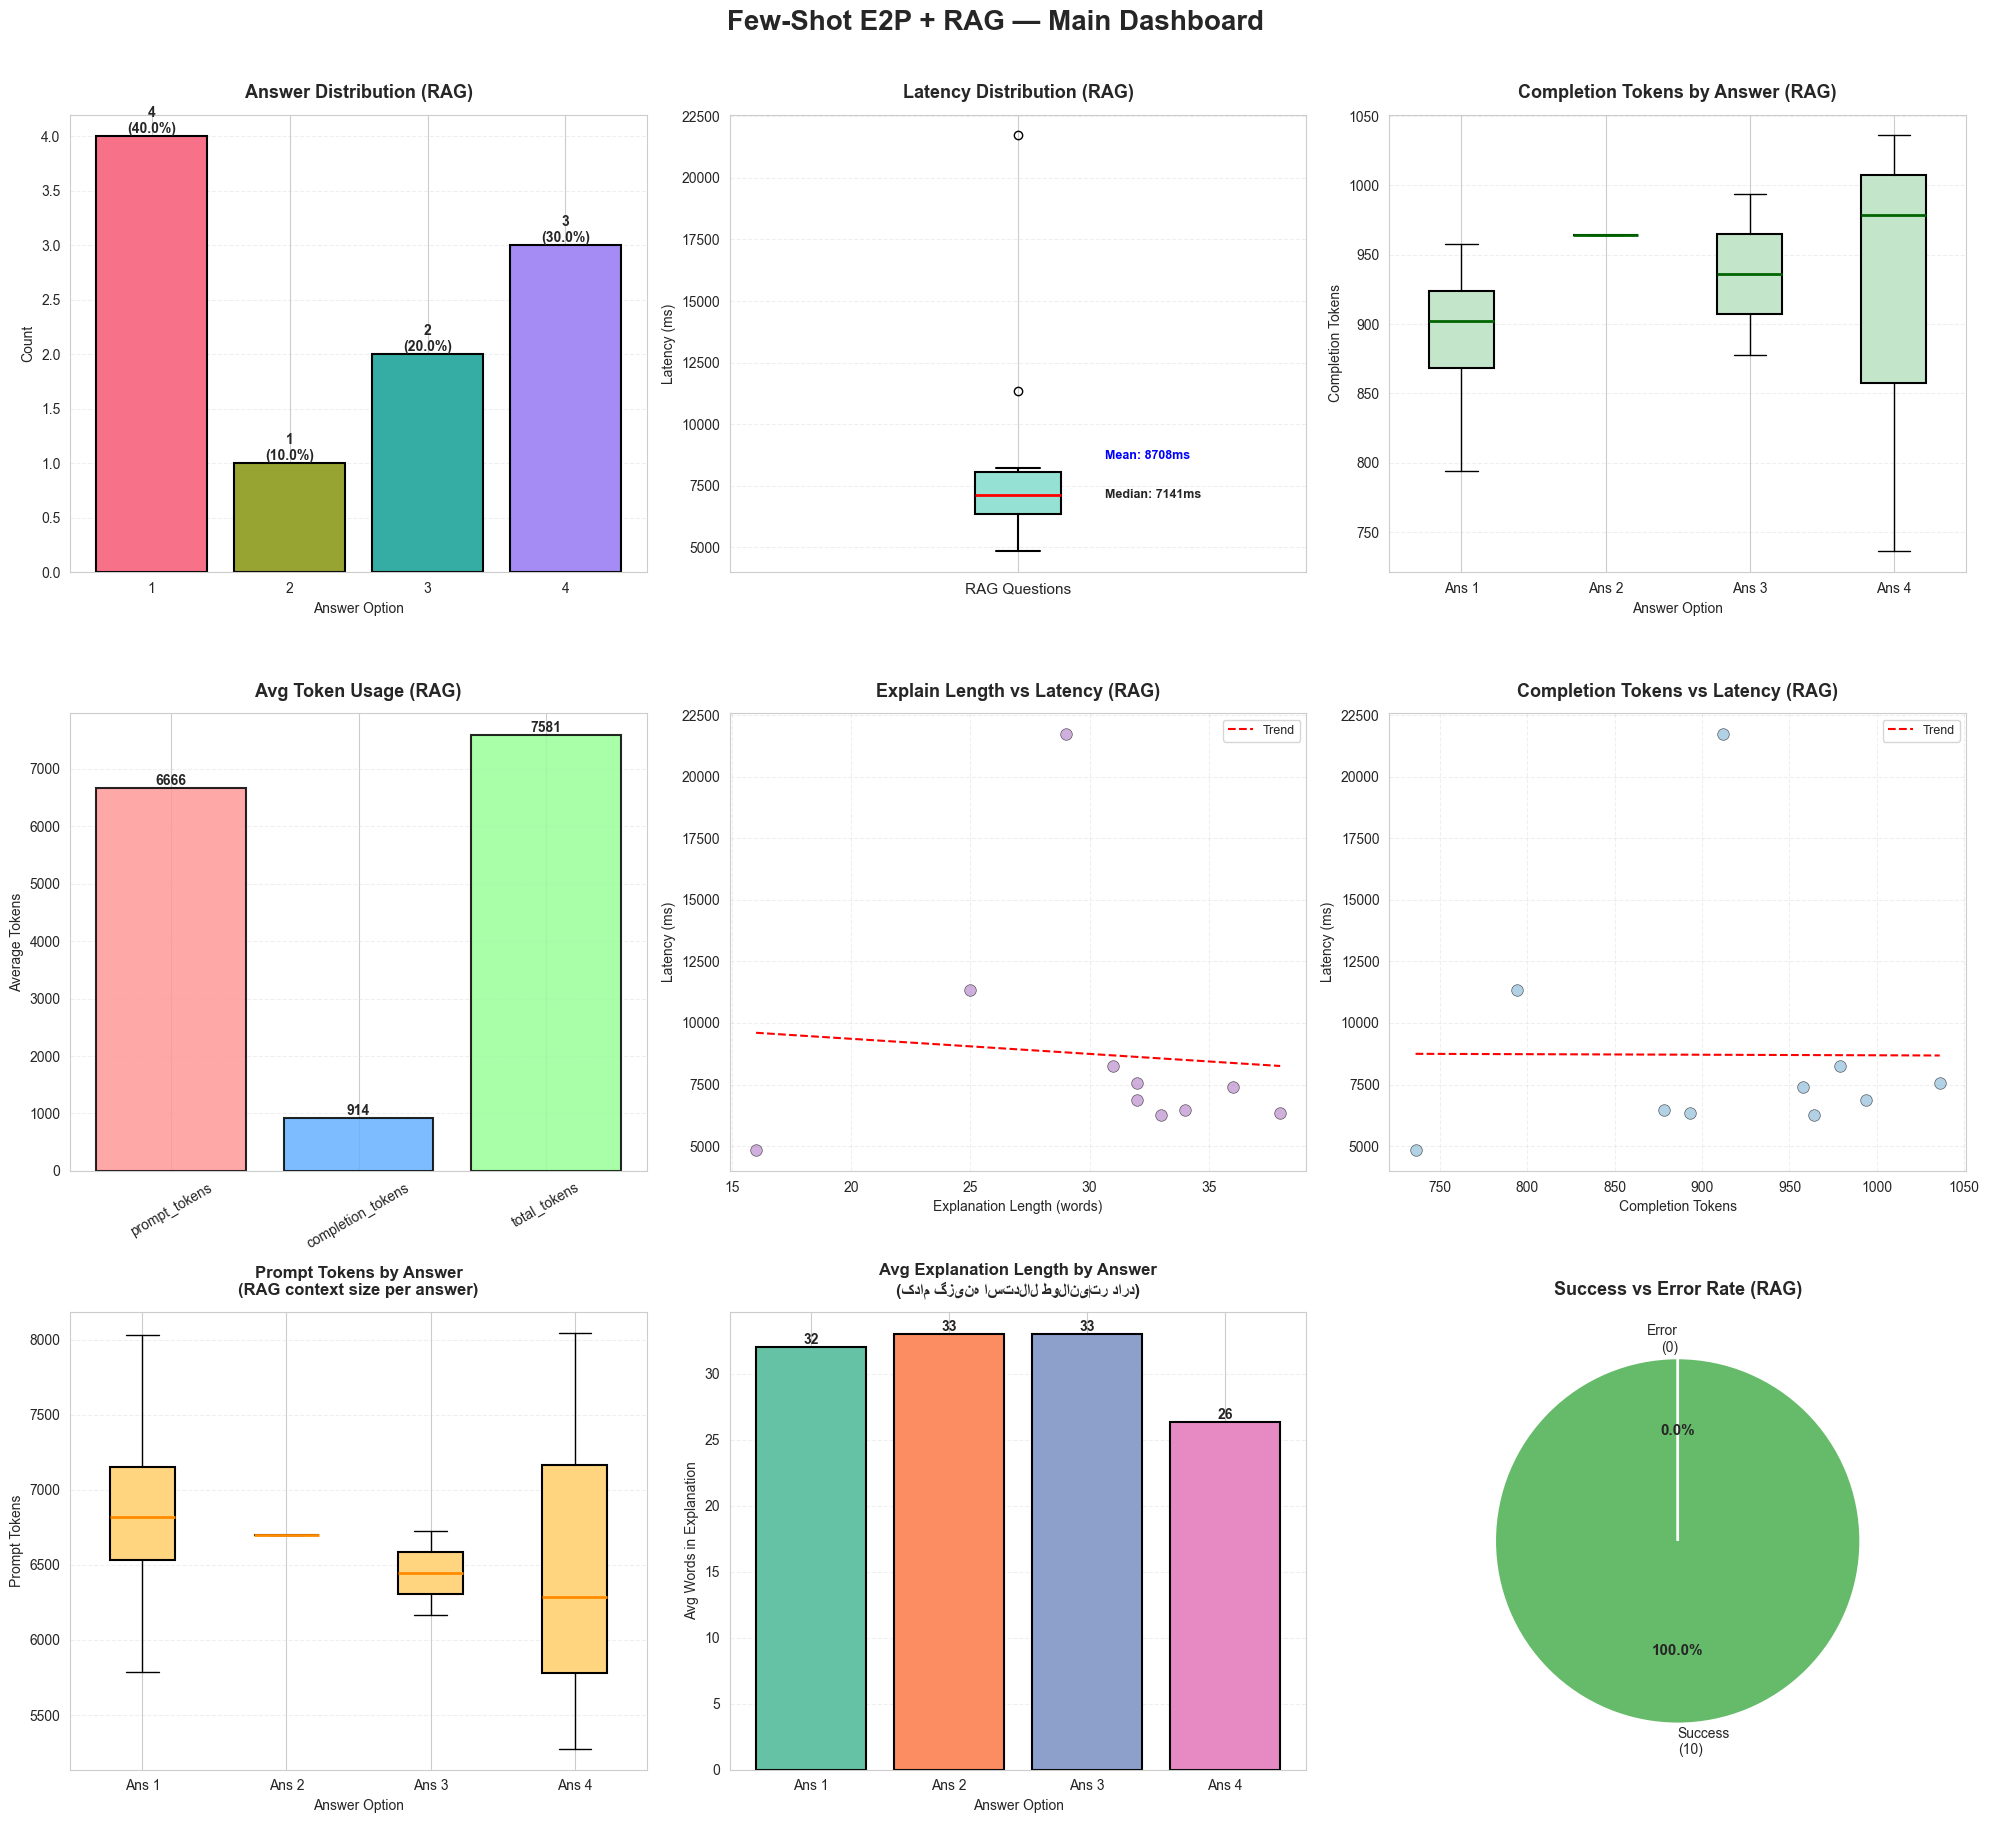


📊 Generating correlation heatmap...
   ✅ Heatmap saved: output\viz_RAG_correlation_heatmap.png


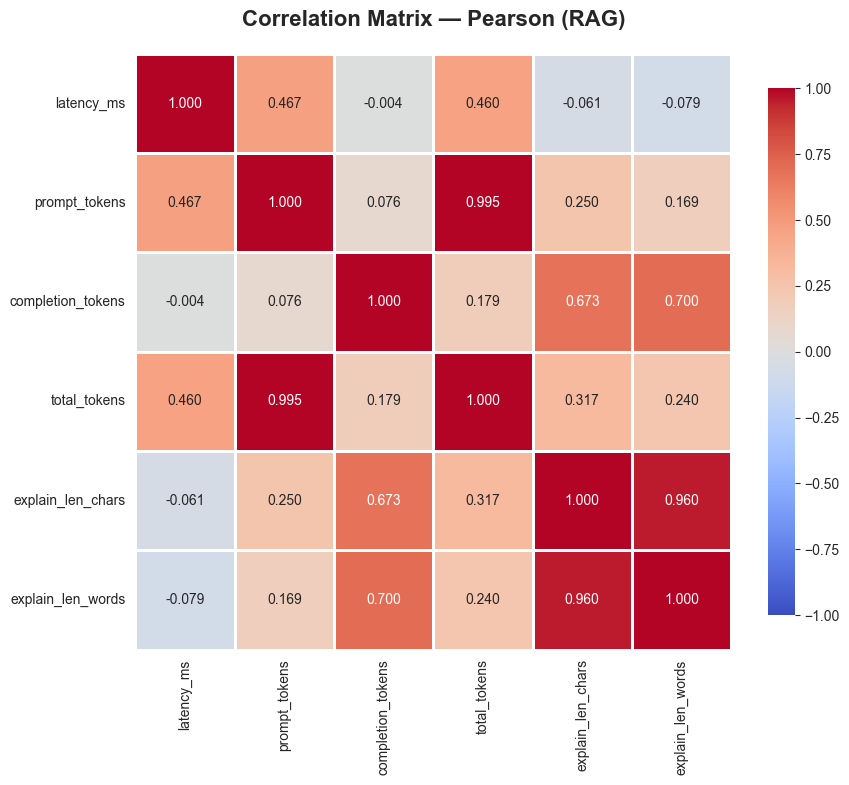


📊 Generating latency timeline...
   ✅ Timeline saved: output\viz_RAG_latency_timeline.png


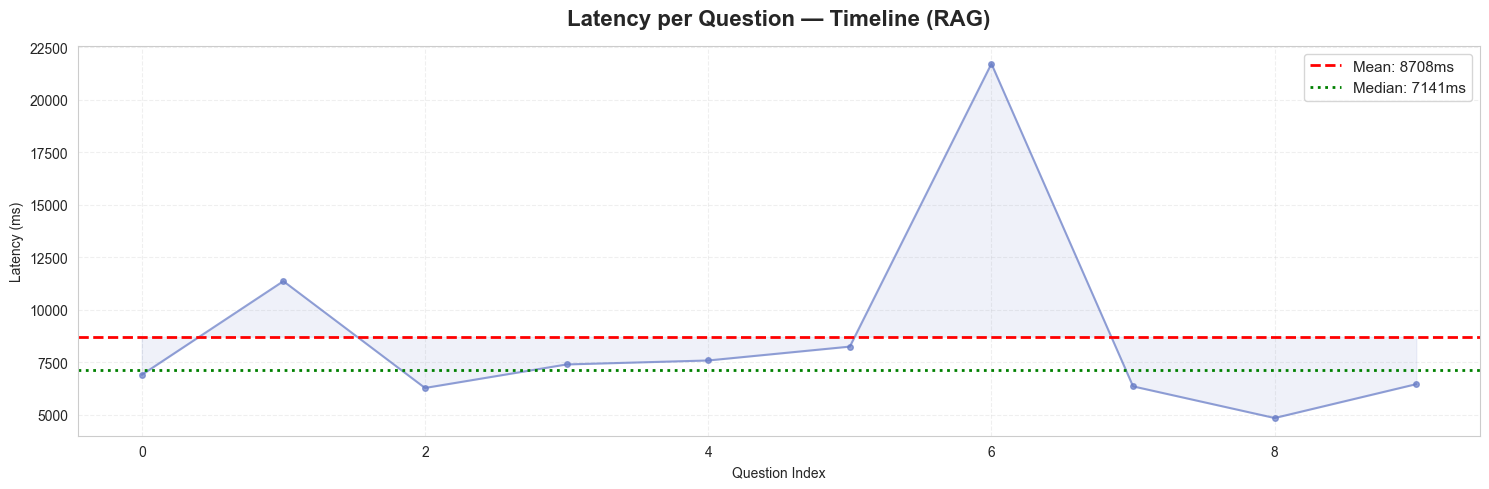


📊 Generating RAG prompt-token distribution...
   ✅ RAG context analysis saved: output\viz_RAG_prompt_token_analysis.png


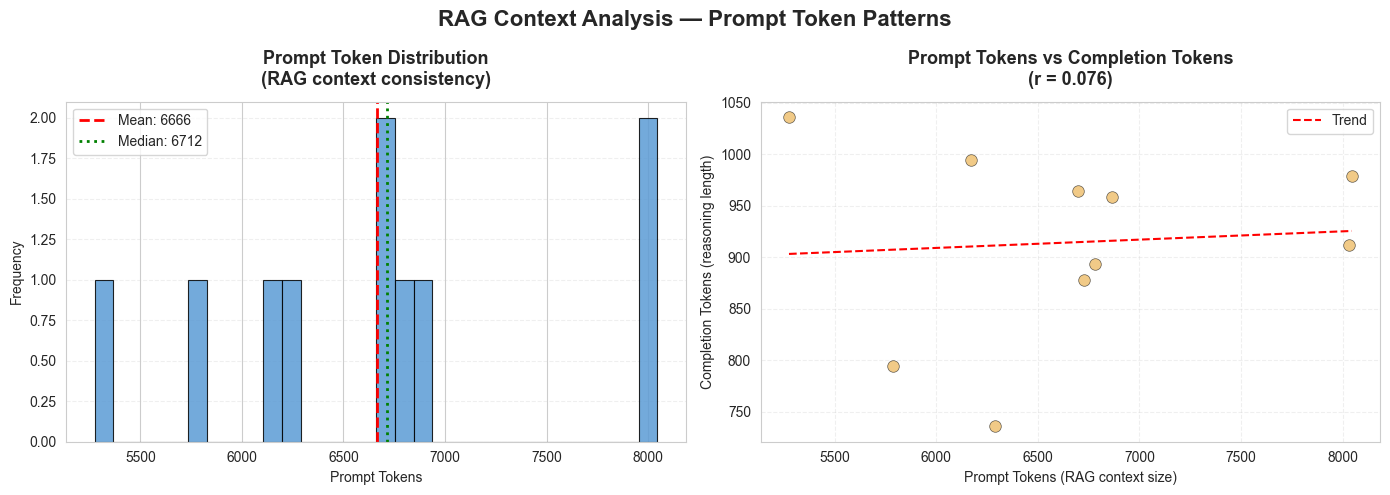


✅ All RAG visualizations generated successfully!


In [8]:
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

plt.rcParams['font.family'] = 'Arial'
sns.set_style("whitegrid")
sns.set_palette("husl")

outdir = Path("output")
outdir.mkdir(exist_ok=True)

print("\n" + "=" * 70)
print("📊 Generating RAG Visualizations")
print("=" * 70)


# ─────────────────────────────────────────────
# FIG 1 — داشبورد اصلی (3×3)
# ─────────────────────────────────────────────
fig, axes = plt.subplots(3, 3, figsize=(20, 18))
axes = axes.flatten()
total_n = len(results)

# ── ax0: توزیع پاسخ‌ها ──
ax = axes[0]
if 'answer' in results.columns and results['answer'].notna().any():
    answer_counts = results['answer'].dropna().astype(str).value_counts().sort_index()
    colors = sns.color_palette("husl", len(answer_counts))
    bars = ax.bar(answer_counts.index, answer_counts.values,
                  color=colors, edgecolor='black', linewidth=1.5)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h,
                f'{int(h)}\n({h / total_n * 100:.1f}%)',
                ha='center', va='bottom', fontsize=10, fontweight='bold')
    ax.set_title('Answer Distribution (RAG)', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Answer Option')
    ax.set_ylabel('Count')
    ax.grid(axis='y', alpha=0.3, linestyle='--')
else:
    ax.text(0.5, 0.5, 'No answer data', ha='center', va='center'); ax.axis('off')

# ── ax1: Boxplot latency ──
ax = axes[1]
if 'latency_ms' in results.columns and results['latency_ms'].notna().any():
    valid_lat = results['latency_ms'].dropna()
    ax.boxplot(valid_lat, vert=True, patch_artist=True,
               boxprops=dict(facecolor='#95E1D3', edgecolor='black', linewidth=1.5),
               whiskerprops=dict(color='black', linewidth=1.5),
               capprops=dict(color='black', linewidth=1.5),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title('Latency Distribution (RAG)', fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Latency (ms)')
    ax.set_xticklabels(['RAG Questions'], fontsize=11)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.text(1.15, valid_lat.median(), f'Median: {valid_lat.median():.0f}ms',
            fontsize=9, fontweight='bold', va='center')
    ax.text(1.15, valid_lat.mean(), f'Mean: {valid_lat.mean():.0f}ms',
            fontsize=9, fontweight='bold', va='center', color='blue')
else:
    ax.text(0.5, 0.5, 'No latency data', ha='center', va='center'); ax.axis('off')

# ── ax2: Completion tokens by answer ──
ax = axes[2]
if {'completion_tokens', 'answer'}.issubset(results.columns):
    grp = results.dropna(subset=['completion_tokens', 'answer']).copy()
    if len(grp) > 0:
        ans_order = sorted(grp['answer'].astype(str).unique())
        data = [grp.loc[grp['answer'].astype(str) == a, 'completion_tokens'] for a in ans_order]
        ax.boxplot(data, labels=[f'Ans {a}' for a in ans_order], patch_artist=True,
                   boxprops=dict(facecolor='#C3E6CB', edgecolor='black', linewidth=1.5),
                   medianprops=dict(color='darkgreen', linewidth=2))
        ax.set_title('Completion Tokens by Answer (RAG)', fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel('Answer Option')
        ax.set_ylabel('Completion Tokens')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center'); ax.axis('off')
else:
    ax.text(0.5, 0.5, 'No data', ha='center', va='center'); ax.axis('off')

# ── ax3: Token usage (mean bars) ──
ax = axes[3]
token_cols = [c for c in ['prompt_tokens', 'completion_tokens', 'total_tokens'] if c in results.columns]
if token_cols:
    token_means = results[token_cols].dropna().mean()
    colors_tok = ['#FF9999', '#66B2FF', '#99FF99']
    bars = ax.bar(token_means.index, token_means.values,
                  color=colors_tok[:len(token_means)], edgecolor='black', linewidth=1.5, alpha=0.85)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2, h, f'{h:.0f}',
                ha='center', va='bottom', fontweight='bold', fontsize=10)
    ax.set_title('Avg Token Usage (RAG)', fontsize=13, fontweight='bold', pad=12)
    ax.set_ylabel('Average Tokens')
    ax.tick_params(axis='x', rotation=30)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
else:
    ax.text(0.5, 0.5, 'No token data', ha='center', va='center'); ax.axis('off')

# ── ax4: Scatter explain_len_words vs latency ──
ax = axes[4]
if {'explain_len_words', 'latency_ms'}.issubset(results.columns):
    sub = results.dropna(subset=['explain_len_words', 'latency_ms'])
    if len(sub) > 1:
        ax.scatter(sub['explain_len_words'], sub['latency_ms'],
                   alpha=0.6, color='#AF7AC5', edgecolors='black', linewidths=0.5, s=70)
        # خط رگرسیون
        z = np.polyfit(sub['explain_len_words'], sub['latency_ms'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(sub['explain_len_words'].min(), sub['explain_len_words'].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend')
        ax.legend(fontsize=9)
        ax.set_title('Explain Length vs Latency (RAG)', fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel('Explanation Length (words)')
        ax.set_ylabel('Latency (ms)')
        ax.grid(alpha=0.3, linestyle='--')
    else:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center'); ax.axis('off')
else:
    ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center'); ax.axis('off')

# ── ax5: Scatter completion_tokens vs latency ──
ax = axes[5]
if {'completion_tokens', 'latency_ms'}.issubset(results.columns):
    sub = results.dropna(subset=['completion_tokens', 'latency_ms'])
    if len(sub) > 1:
        ax.scatter(sub['completion_tokens'], sub['latency_ms'],
                   alpha=0.6, color='#7FB3D5', edgecolors='black', linewidths=0.5, s=70)
        z = np.polyfit(sub['completion_tokens'], sub['latency_ms'], 1)
        p = np.poly1d(z)
        x_line = np.linspace(sub['completion_tokens'].min(), sub['completion_tokens'].max(), 100)
        ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend')
        ax.legend(fontsize=9)
        ax.set_title('Completion Tokens vs Latency (RAG)', fontsize=13, fontweight='bold', pad=12)
        ax.set_xlabel('Completion Tokens')
        ax.set_ylabel('Latency (ms)')
        ax.grid(alpha=0.3, linestyle='--')
    else:
        ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center'); ax.axis('off')
else:
    ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center'); ax.axis('off')

# ── ax6: [RAG-specific] Prompt tokens by answer — آیا RAG context برای گزینه‌ها فرق می‌کند؟ ──
ax = axes[6]
if {'prompt_tokens', 'answer'}.issubset(results.columns):
    grp = results.dropna(subset=['prompt_tokens', 'answer']).copy()
    if len(grp) > 0:
        ans_order = sorted(grp['answer'].astype(str).unique())
        data = [grp.loc[grp['answer'].astype(str) == a, 'prompt_tokens'] for a in ans_order]
        bp = ax.boxplot(data, labels=[f'Ans {a}' for a in ans_order], patch_artist=True,
                        boxprops=dict(facecolor='#FFD580', edgecolor='black', linewidth=1.5),
                        medianprops=dict(color='darkorange', linewidth=2))
        ax.set_title('Prompt Tokens by Answer\n(RAG context size per answer)', fontsize=12, fontweight='bold', pad=12)
        ax.set_xlabel('Answer Option')
        ax.set_ylabel('Prompt Tokens')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center'); ax.axis('off')
else:
    ax.text(0.5, 0.5, 'No data', ha='center', va='center'); ax.axis('off')

# ── ax7: [RAG-specific] explain_len_words by answer ──
ax = axes[7]
if {'explain_len_words', 'answer'}.issubset(results.columns):
    grp = results.dropna(subset=['explain_len_words', 'answer']).copy()
    if len(grp) > 0:
        ans_order = sorted(grp['answer'].astype(str).unique())
        means = [grp.loc[grp['answer'].astype(str) == a, 'explain_len_words'].mean() for a in ans_order]
        colors = sns.color_palette("Set2", len(ans_order))
        bars = ax.bar([f'Ans {a}' for a in ans_order], means, color=colors,
                      edgecolor='black', linewidth=1.5)
        for bar, m in zip(bars, means):
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height(),
                    f'{m:.0f}', ha='center', va='bottom', fontweight='bold', fontsize=10)
        ax.set_title('Avg Explanation Length by Answer\n(کدام گزینه استدلال طولانی‌تر دارد)', fontsize=12, fontweight='bold', pad=12)
        ax.set_xlabel('Answer Option')
        ax.set_ylabel('Avg Words in Explanation')
        ax.grid(axis='y', alpha=0.3, linestyle='--')
    else:
        ax.text(0.5, 0.5, 'No data', ha='center', va='center'); ax.axis('off')
else:
    ax.text(0.5, 0.5, 'No data', ha='center', va='center'); ax.axis('off')

# ── ax8: Error rate ──
ax = axes[8]
if 'error' in results.columns:
    n_errors  = results['error'].notna().sum()
    n_success = total_n - n_errors
    wedges, texts, autotexts = ax.pie(
        [n_success, n_errors],
        labels=[f'Success\n({n_success})', f'Error\n({n_errors})'],
        autopct='%1.1f%%',
        colors=['#66BB6A', '#EF5350'],
        startangle=90,
        wedgeprops=dict(edgecolor='white', linewidth=2)
    )
    for at in autotexts:
        at.set_fontsize(11); at.set_fontweight('bold')
    ax.set_title('Success vs Error Rate (RAG)', fontsize=13, fontweight='bold', pad=12)
else:
    ax.text(0.5, 0.5, 'No error column', ha='center', va='center'); ax.axis('off')

plt.suptitle('Few-Shot E2P + RAG — Main Dashboard', fontsize=20, fontweight='bold', y=1.01)
plt.tight_layout()
p1 = outdir / 'viz_RAG_dashboard.png'
plt.savefig(p1, dpi=300, bbox_inches='tight', facecolor='white')
print(f"   ✅ Dashboard saved: {p1}")
plt.show()
plt.close()


# ─────────────────────────────────────────────
# FIG 2 — Correlation Heatmap
# ─────────────────────────────────────────────
print("\n📊 Generating correlation heatmap...")
numeric_cols = [c for c in [
    'latency_ms', 'prompt_tokens', 'completion_tokens',
    'total_tokens', 'explain_len_chars', 'explain_len_words'
] if c in results.columns]

if len(numeric_cols) >= 2:
    fig2, ax = plt.subplots(figsize=(9, 8))
    corr_data = results[numeric_cols].corr(method='pearson')
    sns.heatmap(corr_data, annot=True, fmt='.3f', cmap='coolwarm', center=0,
                square=True, linewidths=2, cbar_kws={"shrink": 0.8},
                ax=ax, vmin=-1, vmax=1)
    ax.set_title('Correlation Matrix — Pearson (RAG)', fontsize=16, fontweight='bold', pad=20)
    plt.tight_layout()
    p2 = outdir / 'viz_RAG_correlation_heatmap.png'
    plt.savefig(p2, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"   ✅ Heatmap saved: {p2}")
    plt.show()
    plt.close()
else:
    print("   ⚠️ Not enough numeric columns for heatmap")


# ─────────────────────────────────────────────
# FIG 3 — Latency Timeline
# ─────────────────────────────────────────────
print("\n📊 Generating latency timeline...")
if 'latency_ms' in results.columns and results['latency_ms'].notna().any():
    valid_lat = results['latency_ms'].dropna()
    fig3, ax = plt.subplots(figsize=(15, 5))
    ax.plot(range(len(valid_lat)), valid_lat.values,
            marker='o', linestyle='-', linewidth=1.5,
            markersize=4, color='#667BC6', alpha=0.7)
    ax.axhline(valid_lat.mean(), color='red', linestyle='--', linewidth=2,
               label=f'Mean: {valid_lat.mean():.0f}ms')
    ax.axhline(valid_lat.median(), color='green', linestyle=':', linewidth=2,
               label=f'Median: {valid_lat.median():.0f}ms')
    ax.fill_between(range(len(valid_lat)), valid_lat.values,
                    valid_lat.mean(), alpha=0.1, color='#667BC6')
    ax.set_title('Latency per Question — Timeline (RAG)', fontsize=16, fontweight='bold', pad=15)
    ax.set_xlabel('Question Index')
    ax.set_ylabel('Latency (ms)')
    ax.legend(fontsize=11)
    ax.grid(alpha=0.3, linestyle='--')
    plt.tight_layout()
    p3 = outdir / 'viz_RAG_latency_timeline.png'
    plt.savefig(p3, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"   ✅ Timeline saved: {p3}")
    plt.show()
    plt.close()
else:
    print("   ⚠️ No latency data for timeline")


# ─────────────────────────────────────────────
# FIG 4 — [RAG-specific] Prompt tokens distribution
# بررسی اینکه RAG context چقدر یکنواخت بوده
# ─────────────────────────────────────────────
print("\n📊 Generating RAG prompt-token distribution...")
if 'prompt_tokens' in results.columns and results['prompt_tokens'].notna().any():
    fig4, axes4 = plt.subplots(1, 2, figsize=(14, 5))

    # Histogram توزیع prompt tokens
    ax = axes4[0]
    pt = results['prompt_tokens'].dropna()
    ax.hist(pt, bins=30, color='#5B9BD5', edgecolor='black', linewidth=0.8, alpha=0.85)
    ax.axvline(pt.mean(),   color='red',   linestyle='--', linewidth=2, label=f'Mean: {pt.mean():.0f}')
    ax.axvline(pt.median(), color='green', linestyle=':',  linewidth=2, label=f'Median: {pt.median():.0f}')
    ax.set_title('Prompt Token Distribution\n(RAG context consistency)', fontsize=13, fontweight='bold', pad=12)
    ax.set_xlabel('Prompt Tokens')
    ax.set_ylabel('Frequency')
    ax.legend(fontsize=10)
    ax.grid(axis='y', alpha=0.3, linestyle='--')

    # Scatter: prompt_tokens vs completion_tokens
    # آیا context بزرگ‌تر باعث پاسخ طولانی‌تر می‌شود؟
    ax = axes4[1]
    if 'completion_tokens' in results.columns:
        sub = results.dropna(subset=['prompt_tokens', 'completion_tokens'])
        if len(sub) > 1:
            ax.scatter(sub['prompt_tokens'], sub['completion_tokens'],
                       alpha=0.6, color='#E8A838', edgecolors='black', linewidths=0.5, s=70)
            z = np.polyfit(sub['prompt_tokens'], sub['completion_tokens'], 1)
            p = np.poly1d(z)
            x_line = np.linspace(sub['prompt_tokens'].min(), sub['prompt_tokens'].max(), 100)
            ax.plot(x_line, p(x_line), 'r--', linewidth=1.5, label='Trend')
            corr = sub[['prompt_tokens', 'completion_tokens']].corr().iloc[0, 1]
            ax.set_title(f'Prompt Tokens vs Completion Tokens\n(r = {corr:.3f})',
                         fontsize=13, fontweight='bold', pad=12)
            ax.set_xlabel('Prompt Tokens (RAG context size)')
            ax.set_ylabel('Completion Tokens (reasoning length)')
            ax.legend(fontsize=10)
            ax.grid(alpha=0.3, linestyle='--')
        else:
            ax.text(0.5, 0.5, 'Insufficient data', ha='center', va='center'); ax.axis('off')
    else:
        ax.text(0.5, 0.5, 'No completion_tokens', ha='center', va='center'); ax.axis('off')

    plt.suptitle('RAG Context Analysis — Prompt Token Patterns', fontsize=16, fontweight='bold')
    plt.tight_layout()
    p4 = outdir / 'viz_RAG_prompt_token_analysis.png'
    plt.savefig(p4, dpi=300, bbox_inches='tight', facecolor='white')
    print(f"   ✅ RAG context analysis saved: {p4}")
    plt.show()
    plt.close()
else:
    print("   ⚠️ No prompt_tokens data")


print("\n" + "=" * 70)
print("✅ All RAG visualizations generated successfully!")
print("=" * 70)